<a href="https://colab.research.google.com/github/letruc271193-dot/btvn/blob/main/nhandienface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU
# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/anhai/Ảnh selfie cho chiều t2 18 5"

# Kích thước ảnh và kích thước lô
img_width, img_height = 200,200
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 2127 images belonging to 36 classes.


In [13]:
# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Reduce overfitting
    Dense(36, activation="softmax") # 5 categories
])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,765,156 (33.44 MB)

 Trainable params: 8,765,156 (33.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 37s 491ms/step - accuracy: 0.0724 - loss: 3.4924
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 443ms/step - accuracy: 0.1885 - loss: 2.9689
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 446ms/step - accuracy: 0.2971 - loss: 2.5378
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.3587 - loss: 2.2812
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 29s 437ms/step - accuracy: 0.4556 - loss: 1.9200
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 29s 441ms/step - accuracy: 0.5106 - loss: 1.7860
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 446ms/step - accuracy: 0.5665 - loss: 1.5849
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 441ms/step - accuracy: 0.5816 - loss: 1.4764
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 437ms/step - accuracy: 0.6018 - loss: 1.4018
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 438ms/step - accuracy: 0.6512 - loss: 1.2646
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 30s 442ms/step - accuracy: 0.6554 - loss: 1.2443
Epoch 12/100
67/67 ━━━━━━━━━━━

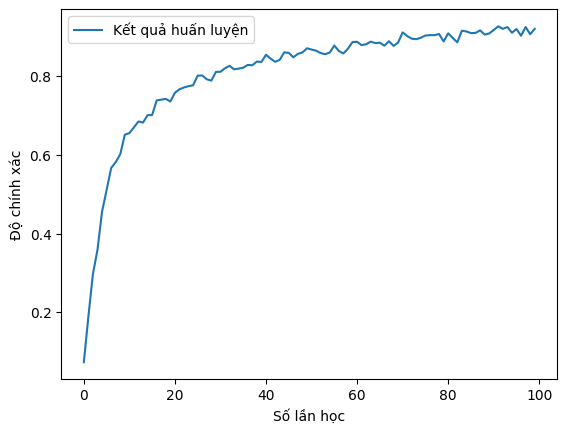

In [14]:
# Biên dịch mô hình
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 100
history = model.fit(train_generator, epochs=epochs)

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
# Kiểm tra nếu có dữ liệu xác thực mới vẽ để tránh lỗi KeyError
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")

plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

In [16]:
import pickle # Thư viện dùng để lưu danh sách tên người

# 1. LƯU MÔ HÌNH VÀO GOOGLE DRIVE
# Bạn lưu thẳng vào thư mục 'anhai' trên Drive của bạn để không bị mất khi tắt Colab
model.save('/content/drive/MyDrive/anhai/my_face_model.h5')

# 2. LƯU LẠI DANH SÁCH NHÃN (Tên người)
# Rất cần thiết vì nếu lần sau không chạy train_generator, bạn sẽ mất biến class_indices
with open('/content/drive/MyDrive/anhai/class_labels.pkl', 'wb') as f:
    pickle.dump(train_generator.class_indices, f)

print("Đã lưu mô hình và nhãn thành công vào Google Drive!")

Đã lưu mô hình và nhãn thành công vào Google Drive!


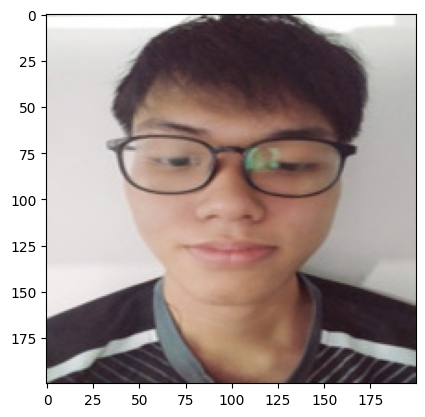

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Người tiên đoán: Lê Minh Huy


In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt
import pickle

# --- BƯỚC 1: TẢI MÔ HÌNH ĐÃ LƯU TỪ TRƯỚC ---
model = load_model('/content/drive/MyDrive/anhai/my_face_model.h5')

# --- BƯỚC 2: TẢI DANH SÁCH TÊN NGƯỜI (NHÃN) ---
with open('/content/drive/MyDrive/anhai/class_labels.pkl', 'rb') as f:
    class_indices = pickle.load(f)
# Ánh xạ lại dictionary (Đảo key-value)
class_labels = {v: k for k, v in class_indices.items()}


# --- BƯỚC 3: DỰ ĐOÁN ẢNH MỚI ---
# (Đoạn này giống hệt code cũ của bạn)
path = "/content/anh1.jpg" # Đường dẫn tới ảnh bạn muốn kiểm tra
img = load_img(path, target_size=(200,200))
plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 200, 200, 3)

# Tiên đoán (Giống bước Start predicting trong ảnh của bạn)
prediction = np.argmax(model.predict(img))
person_name = class_labels[prediction]

print(f"Người tiên đoán: {person_name}")